# <font color = #84c4da >**Bank Customer Churn Prediction** </font>

## **Descripción del dataset**

Dataset del banco multiestatal **ABC** con información de clientes para predecir si abandonarán el banco.

| Columna | Tipo | Descripción |
|---|---|---|
| customer_id | — | ID del cliente, no se usa como feature |
| credit_score | Input | Puntaje de crédito del cliente |
| country | Input | País del cliente |
| gender | Input | Género del cliente |
| age | Input | Edad del cliente |
| tenure | Input | Años como cliente del banco |
| balance | Input | Saldo en cuenta |
| products_number | Input | Número de productos contratados |
| credit_card | Input | Si tiene tarjeta de crédito (1/0) |
| active_member | Input | Si es miembro activo (1/0) |
| estimated_salary | Input | Salario estimado |
| **churn** | **Target**| 1 = abandonó el banco, 0 = se quedó |

## <font color = #84c4da >**Objetivo** </font>
**Clasificación binaria: predecir si un cliente va a abandonar el banco.**

## <font color= #83eac2 >**1. Importaciones** </font>

---

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, balanced_accuracy_score, ConfusionMatrixDisplay)
import pickle

## <font color= #83eac2 >**2. Cargar y revisión de datos** </font>

---

In [2]:
df = pd.read_csv('../data/Bank Customer Churn Prediction.csv')
print(f'Shape: {df.shape}')

Shape: (10000, 12)


In [3]:
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [5]:
df.describe()

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [6]:
# Verificación de duplicados
print(f'Filas duplicadas: {df.duplicated().sum()}')

Filas duplicadas: 0


In [7]:
# Verificando valores Nulos
df.isnull().all()

customer_id         False
credit_score        False
country             False
gender              False
age                 False
tenure              False
balance             False
products_number     False
credit_card         False
active_member       False
estimated_salary    False
churn               False
dtype: bool

In [8]:
# Eliminar columna customer_id
df = df.drop(columns=['customer_id'])

In [9]:
# Ver Distribución del target
df.churn.value_counts()

churn
0    7963
1    2037
Name: count, dtype: int64

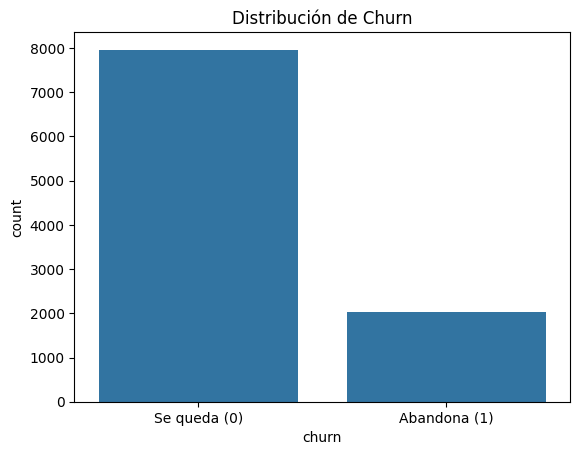

In [10]:
# Distribución del target
sns.countplot(x='churn', data=df)
plt.title('Distribución de Churn')
plt.xticks([0, 1], ['Se queda (0)', 'Abandona (1)'])
plt.show()


## <font color= #83eac2 >**3. División Train y Test** </font>

---

In [11]:
X = df.drop(columns=['churn'])
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=42, stratify=y)   # stratify -->importante por el desbalanceo

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")

print(f"\nDistribución y_train:\n{y_train.value_counts(normalize=True)}")
print(f"\nDistribución y_test:\n{y_test.value_counts(normalize=True)}")

X_train: (8000, 10)
X_test:  (2000, 10)

Distribución y_train:
churn
0    0.79625
1    0.20375
Name: proportion, dtype: float64

Distribución y_test:
churn
0    0.7965
1    0.2035
Name: proportion, dtype: float64


In [12]:
def card_tipo(df,umbral_categoria = 10, umbral_continua = 30):
    # Primera parte: Preparo el dataset con cardinalidades, % variación cardinalidad, y tipos
    df_temp = pd.DataFrame([df.nunique(), df.nunique()/len(df) * 100, df.dtypes]) # Cardinaliad y porcentaje de variación de cardinalidad
    df_temp = df_temp.T # Como nos da los valores de las columnas en columnas, y quiero que estas sean filas, la traspongo
    df_temp = df_temp.rename(columns = {0: "Card", 1: "%_Card", 2: "Tipo"}) # Cambio el nombre de la transposición anterior para que tengan más sentido, y uso asignación en vez de inplace = True (esto es arbitrario para el tamaño de este dataset)

    # Corrección para cuando solo tengo un valor
    df_temp.loc[df_temp.Card == 1, "%_Card"] = 0.00

    # Creo la columna de sugerenica de tipo de variable, empiezo considerando todas categóricas pero podría haber empezado por cualquiera, siempre que adapte los filtros siguientes de forma correspondiente
    df_temp["tipo_sugerido"] = "Categorica"
    df_temp.loc[df_temp["Card"] == 2, "tipo_sugerido"] = "Binaria"
    df_temp.loc[df_temp["Card"] >= umbral_categoria, "tipo_sugerido"] = "Numerica discreta"
    df_temp.loc[df_temp["%_Card"] >= umbral_continua, "tipo_sugerido"] = "Numerica continua"
    # Ojo los filtros aplicados cumplen con el enunciado pero no siguen su orden y planteamiento

    return df_temp

In [13]:
# Tipos de datos seguridos según función
card_columnas = card_tipo(df)
card_columnas

,Card,%_Card,Tipo,tipo_sugerido
credit_score,460,4.6,int64,Numerica discreta
country,3,0.03,object,Categorica
gender,2,0.02,object,Binaria
age,70,0.7,int64,Numerica discreta
tenure,11,0.11,int64,Numerica discreta
balance,6382,63.82,float64,Numerica continua
products_number,4,0.04,int64,Categorica
credit_card,2,0.02,int64,Binaria
active_member,2,0.02,int64,Binaria
estimated_salary,9999,99.99,float64,Numerica continua


## <font color= #83eac2 >**4. Definir columnas y ColumnTransformer** </font>

---

In [14]:
X_train.head()

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary
2151,753,France,Male,57,7,0.00,1,1,0,159475.08
8392,739,Germany,Male,32,3,102128.27,1,1,0,63981.37
5006,755,Germany,Female,37,0,113865.23,2,1,1,117396.25
4117,561,France,Male,37,5,0.00,2,1,0,83093.25
7182,692,Germany,Male,49,6,110540.43,2,0,1,107472.99


In [15]:
# Definir columnas
col_numericas = ['credit_score', 'age', 'tenure', 'balance', 'estimated_salary']
col_categoricas = ['country', 'gender', 'products_number']
col_binarias = ['credit_card', 'active_member']  # ya son 0/1, no necesitan transformación


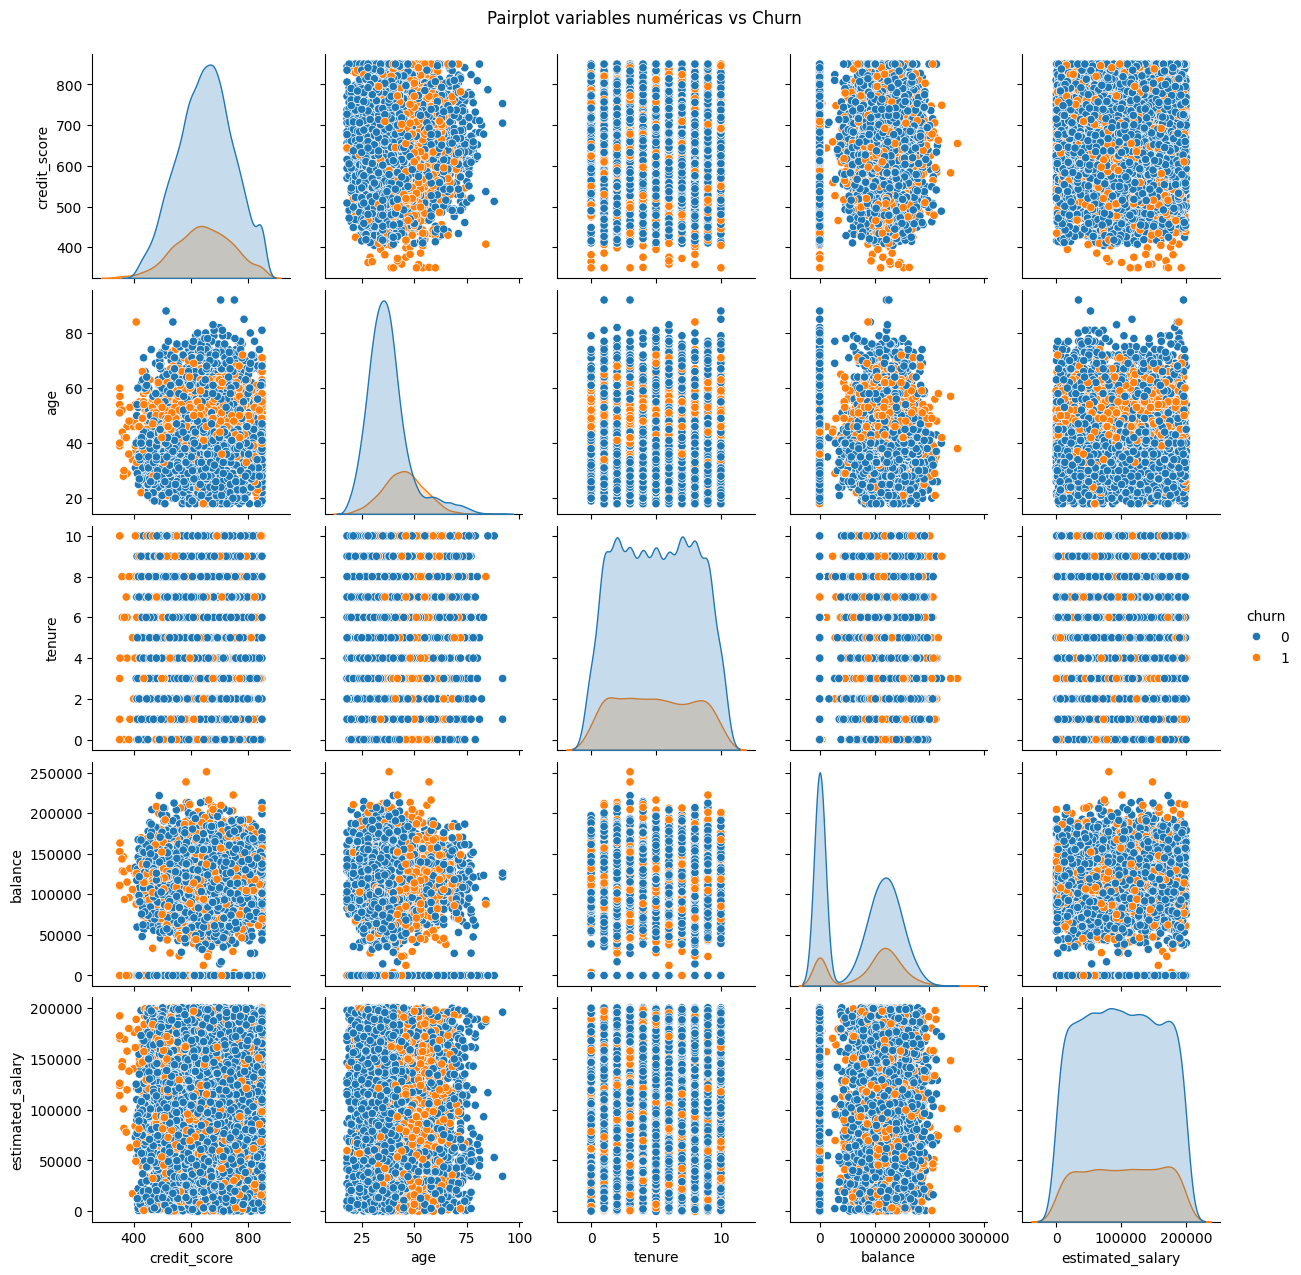

In [16]:
# Pairplot variables numéricas con target
sns.pairplot(df[col_numericas + ['churn']], 
             hue='churn',
             diag_kind='kde')

plt.suptitle('Pairplot variables numéricas vs Churn', y=1.02)
plt.show()

**age**:  Es la variable que mejor separa las clases. Los clientes que abandonan (naranja) tienen una distribución desplazada hacia edades más altas (40-60 años), mientras que los que se quedan (azul) son más jóvenes. Será una feature clave para el modelo.<br>
**balance**: Hay una gran concentración de clientes con balance = 0 que casi todos se quedan (azul). Los clientes con balance alto tienen más churn. Esto sugiere que tener dinero en el banco no garantiza fidelidad.<br>
**credit_score y estimated_salary**: Los puntos naranja y azul están muy mezclados. Estas variables probablemente aportarán poco poder predictivo al modelo.<br>
**tenure**:  La distribución es casi idéntica entre los dos grupos. Los años como cliente no parecen influir mucho en el churn.<br>

In [17]:
#col_numericas = ['credit_score', 'age', 'tenure', 'balance', 'estimated_salary']
#col_categoricas = ['country', 'gender', 'products_number']
#col_binarias = ['credit_card', 'active_member']

# Definir ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), col_numericas),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False), col_categoricas),
    ('bin', 'passthrough', col_binarias)
])

# handle_unknown='ignore' ->si llega un valor nuevo que no vio en entrenamiento, lo ignora en vez de dar error. 
# drop='first' -> Elimina la primera categoría de cada variable para evitar la multicolinealidad.
# sparse_output=False --> Por defecto el OneHotEncoder devuelve una matriz dispersa (sparse) para ahorrar memoria,solo guarda los valores que son 1, no los 0.
# passthrough significa no hacer nada deja credit_card y active_member tal cual porque ya son 0 y 1. No necesitan transformación.


print("ColumnTransformer definido")
print(f"Numéricas ({len(col_numericas)}): {col_numericas}")
print(f"Categóricas ({len(col_categoricas)}): {col_categoricas}")
print(f"Binarias ({len(col_binarias)}): {col_binarias}")



ColumnTransformer definido
Numéricas (5): ['credit_score', 'age', 'tenure', 'balance', 'estimated_salary']
Categóricas (3): ['country', 'gender', 'products_number']
Binarias (2): ['credit_card', 'active_member']


## <font color= #83eac2 >**5. Pipelines y GridSearch** </font>

---

In [18]:
# Pipelines con 3 modelos
pipelines = {
    'Logistic Regression': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(
            class_weight='balanced',
            max_iter=1000,
            solver='saga',
            random_state=42))
    ]),
    'Random Forest': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(
            class_weight='balanced',
            n_jobs=-1,
            random_state=42))
    ]),
    'Gradient Boosting': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', GradientBoostingClassifier(
            random_state=42))
    ])
}

print("Pipelines definidos:")
for nombre in pipelines:
    print(f"  - {nombre}")

Pipelines definidos:
  - Logistic Regression
  - Random Forest
  - Gradient Boosting


In [19]:
# Hiperparámetros para GridSearchCV
param_grids = {
    'Logistic Regression': {
        'classifier__C': [0.01, 5, 10, 20, 100],
        'classifier__l1_ratio': [0, 0.5, 0.7, 1]
    },
    'Random Forest': {
        'classifier__n_estimators': [200, 300, 400],
        'classifier__max_depth': [8, 10,12],
        'classifier__min_samples_split': [4, 5, 6],
        'classifier__min_samples_leaf': [1, 2]

    },
    'Gradient Boosting': {
        'classifier__n_estimators': [100, 150, 200],
        'classifier__learning_rate': [0.05, 0.1, 0.15],
        'classifier__max_depth': [2, 3, 4, 5],
        'classifier__subsample': [0.8, 1.0]

    }
}

# StratifiedKFold por el desbalanceo 80/20
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


In [20]:
#Entrenamiento de todos los modelos
resultados = {}

for nombre, pipeline in pipelines.items():
    print(f"Entrenando {nombre}...")
    
    gs = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grids[nombre],
        cv=cv,
        scoring='roc_auc',
        n_jobs=-1,
        verbose=1
    )
    
    gs.fit(X_train, y_train)
    
    resultados[nombre] = {
        'mejor_modelo': gs.best_estimator_,
        'mejores_params': gs.best_params_,
        'mejor_score_cv': gs.best_score_
    }
    
    print(f"Mejor ROC-AUC (CV): {gs.best_score_:.4f}")
    print(f"Mejores parámetros: {gs.best_params_}\n")


Entrenando Logistic Regression...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejor ROC-AUC (CV): 0.8323
Mejores parámetros: {'classifier__C': 5, 'classifier__l1_ratio': 1}

Entrenando Random Forest...
Fitting 5 folds for each of 54 candidates, totalling 270 fits
Mejor ROC-AUC (CV): 0.8593
Mejores parámetros: {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 300}

Entrenando Gradient Boosting...
Fitting 5 folds for each of 72 candidates, totalling 360 fits
Mejor ROC-AUC (CV): 0.8660
Mejores parámetros: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__n_estimators': 200, 'classifier__subsample': 0.8}



## <font color= #83eac2 >**6. Evaluación de los modelos** </font>

---

In [30]:
# Evaluación de todos los modelos sobre X_test
for nombre, resultado in resultados.items():
    modelo = resultado['mejor_modelo']
    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]
    
    print(f"{'='*50}")
    print(f"{nombre}")
    print(f"{'='*50}")
    print(f"Matriz de confusion:    \n{confusion_matrix(y_test, y_pred, labels=modelo.classes_)}")
    print(f"ROC-AUC test:           {roc_auc_score(y_test, y_prob):.4f}")
    print(f"Balanced Accuracy:      {balanced_accuracy_score(y_test, y_pred):.4f}")
    print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")

Logistic Regression
Matriz de confusion:    
[[1216  377]
 [ 100  307]]
ROC-AUC test:           0.8373
Balanced Accuracy:      0.7588

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.76      0.84      1593
           1       0.45      0.75      0.56       407

    accuracy                           0.76      2000
   macro avg       0.69      0.76      0.70      2000
weighted avg       0.83      0.76      0.78      2000

Random Forest
Matriz de confusion:    
[[1378  215]
 [ 126  281]]
ROC-AUC test:           0.8595
Balanced Accuracy:      0.7777

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.87      0.89      1593
           1       0.57      0.69      0.62       407

    accuracy                           0.83      2000
   macro avg       0.74      0.78      0.76      2000
weighted avg       0.85      0.83      0.84      2000

Gradient Boosting
Matriz de confusio

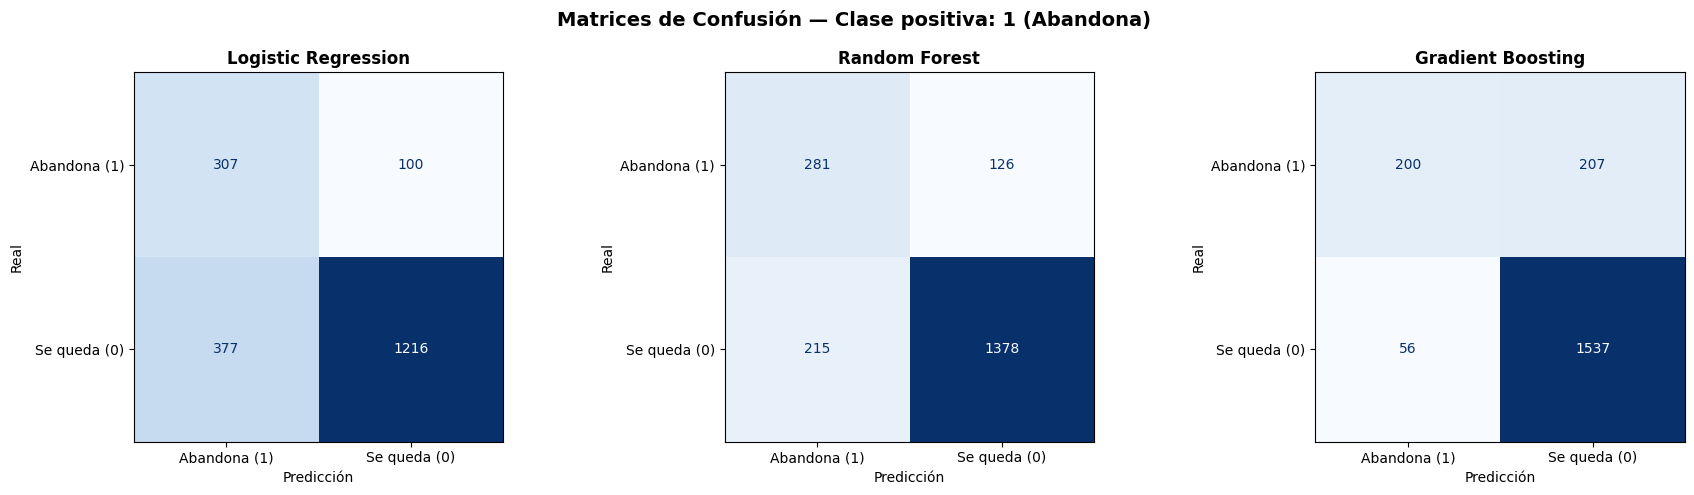

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Matrices de Confusión — Clase positiva: 1 (Abandona)', fontsize=14, fontweight='bold')

for ax, (nombre, resultado) in zip(axes, resultados.items()):
    modelo = resultado['mejor_modelo']
    y_pred = modelo.predict(X_test)
    
    disp = ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        labels=[1, 0],
        display_labels=['Abandona (1)', 'Se queda (0)'],
        colorbar=False,
        cmap='Blues',
        ax=ax
    )
    ax.set_title(nombre, fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicción', fontsize=10)
    ax.set_ylabel('Real', fontsize=10)

plt.tight_layout()
plt.show()

#### <font color= #e1efa9>***Comparativa de modelos***</font><br>

| Modelo | ROC-AUC CV | ROC-AUC test | Balanced Acc | Recall clase 1 | Precision clase 1 |
|---|---|---|---|---|---|
| Logistic Regression | 0.8323 | 0.8373 | 0.7588 | 0.75 | 0.45 |
| Random Forest | 0.8593 | 0.8595 | 0.7777 | 0.69 | 0.57 |
| Gradient Boosting | 0.8660 | 0.8702 | 0.7281 | 0.49 | 0.78 |

#### <font color= #e1efa9>***Modelo seleccionado: Random Forest***</font><br>

Se selecciona **Random Forest** como modelo final por ser el que mejor equilibrio presenta entre todas las métricas evaluadas.<br>

**Gradient Boosting** obtiene el mejor ROC-AUC (0.87) pero su recall de clase 1 es de apenas 0.49, lo que significa que pierde la mitad de los clientes que van a abandonar el banco inaceptable en un problema de churn donde el objetivo principal es detectar y retener clientes. <br>

**Logistic Regression** detecta bien el churn (recall 0.75) pero genera demasiadas falsas alarmas (precision 0.45), lo que implicaría costes innecesarios de retención para el banco.<br>

**Random Forest** ofrece el mejor balance: ROC-AUC de 0.86, Balanced Accuracy de 0.78, y un recall de clase 1 de 0.69 con precision de 0.57 detecta la mayoría de los churners sin disparar demasiadas alertas falsas.

## <font color= #83eac2 >**7. Guardar el modelo** </font>

---

In [33]:
# Guardar el modelo final (Random Forest)
import pickle

modelo_final = resultados['Logistic Regression']['mejor_modelo']

with open('../models/logistic_regression_churn.pkl', 'wb') as f:
    pickle.dump(modelo_final, f)


In [35]:
# Verificar que el modelo carga y predice correctamente
with open('../models/logistic_regression_churn.pkl', 'rb') as f:
    modelo_cargado = pickle.load(f)

# Predicción de prueba con la primera fila de X_test
prueba = X_test.iloc[:1]
prediccion = modelo_cargado.predict(prueba)
probabilidad = modelo_cargado.predict_proba(prueba)[:, 1]

print(f"Predicción: {prediccion[0]} ({'Abandona' if prediccion[0] == 1 else 'Se queda'})")
print(f"Probabilidad de churn: {probabilidad[0]:.4f}")


Predicción: 0 (Se queda)
Probabilidad de churn: 0.1593
